### Mutual Correlation Energy, Orbital Energy Decomposition

In [1]:
import forte2
import numpy as np
from mutual_correlation_energy_mod import twofrag_correlation_energy_enumerated
from plot_correlation_energy import mutual_correlation_plot

In [2]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.740 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   1.39839733   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.217e+00
  Min eigenvalue: 1.591e-03
  Condition number: 2.650e+03
  Inverse condition number: 3.774e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.591e-03
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:

CI(states=State(multiplicity=1, ms=0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 1.39839733, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 28 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 36 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=1, nb=1, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=28, active_orbitals=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_o

In [3]:
MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in orb_list:
    for j in orb_list:
        if i != j: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=hci,A_orbs=[i],B_orbs=[j])
        


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 47 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



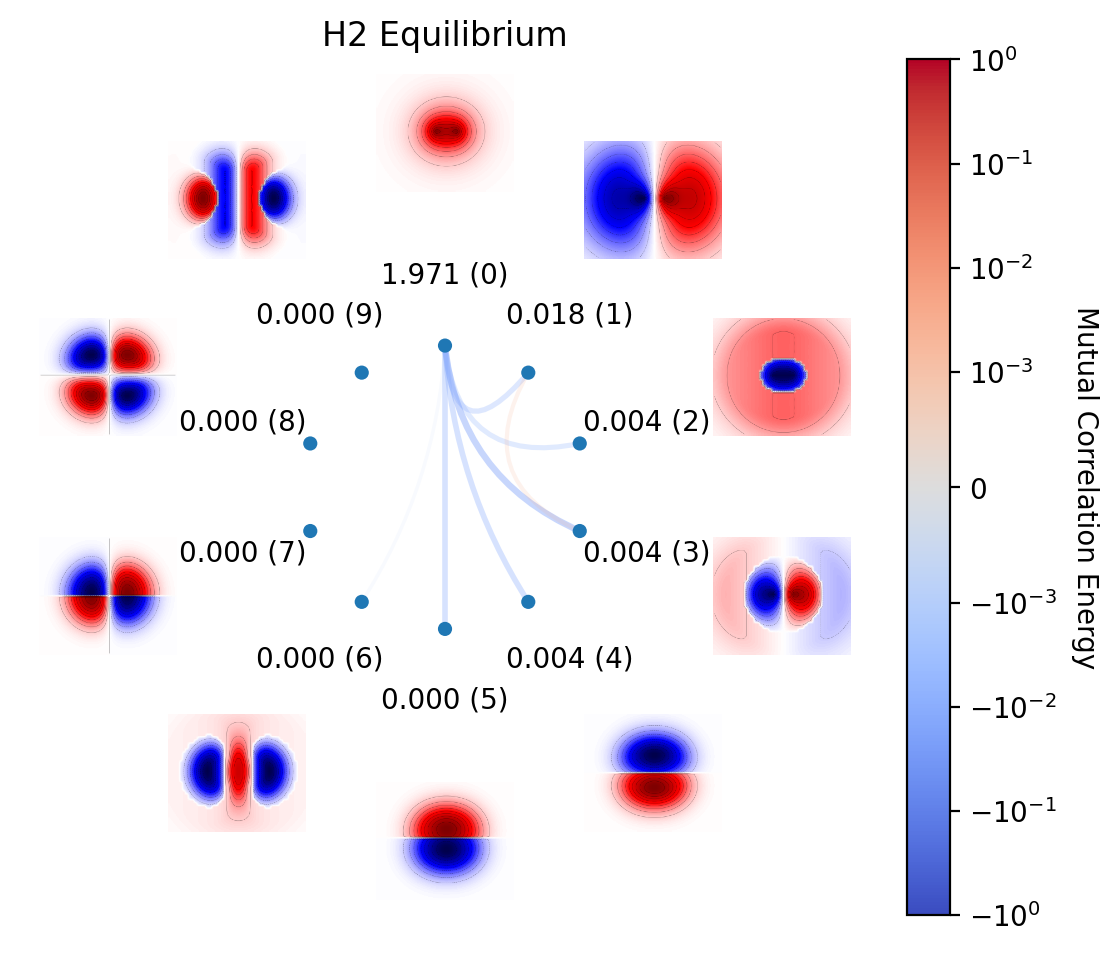

In [4]:
mutual_correlation_plot(system,hci.C[0],
                        indices=hci.mo_space.active_indices,
                        mca=MCEmat,
                        title="H2 Equilibrium",
                        occupation_numbers=hci.nat_occs
                        )

### Some small organic systems

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   -1.74610524
   C   -2.30435717   0.00000000   -0.33782880
   C   -2.29240049   0.00000000   2.28226495
   C   0.00000000   0.00000000   3.61804507
   C   2.29240049   0.00000000   2.28226495
   C   2.30435717   0.00000000   -0.33782880
   H   -4.09358142   0.00000000   -1.36587798
   H   -4.07908326   0.00000000   3.31241362
   H   0.00000000   0.00000000   5.67867047
   H   4.07908326   0.00000000   3.31241362
   H   4.09358142   0.00000000   -1.36587798
   C   0.00000000   0.00000000   -4.40254673
   H   -1.76343138   0.00000000   -5.46500348
   H   1.76343138   0.00000000   -5.46500348
Parsed 14 atoms with basis set of 308 functions.
  Max eigenvalue: 8.077e+00
  Min eigenvalue: 3.538e-05
  Condition number: 2.283e+05
  Inverse condition number: 4.381e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 308
  Largest discarded ei

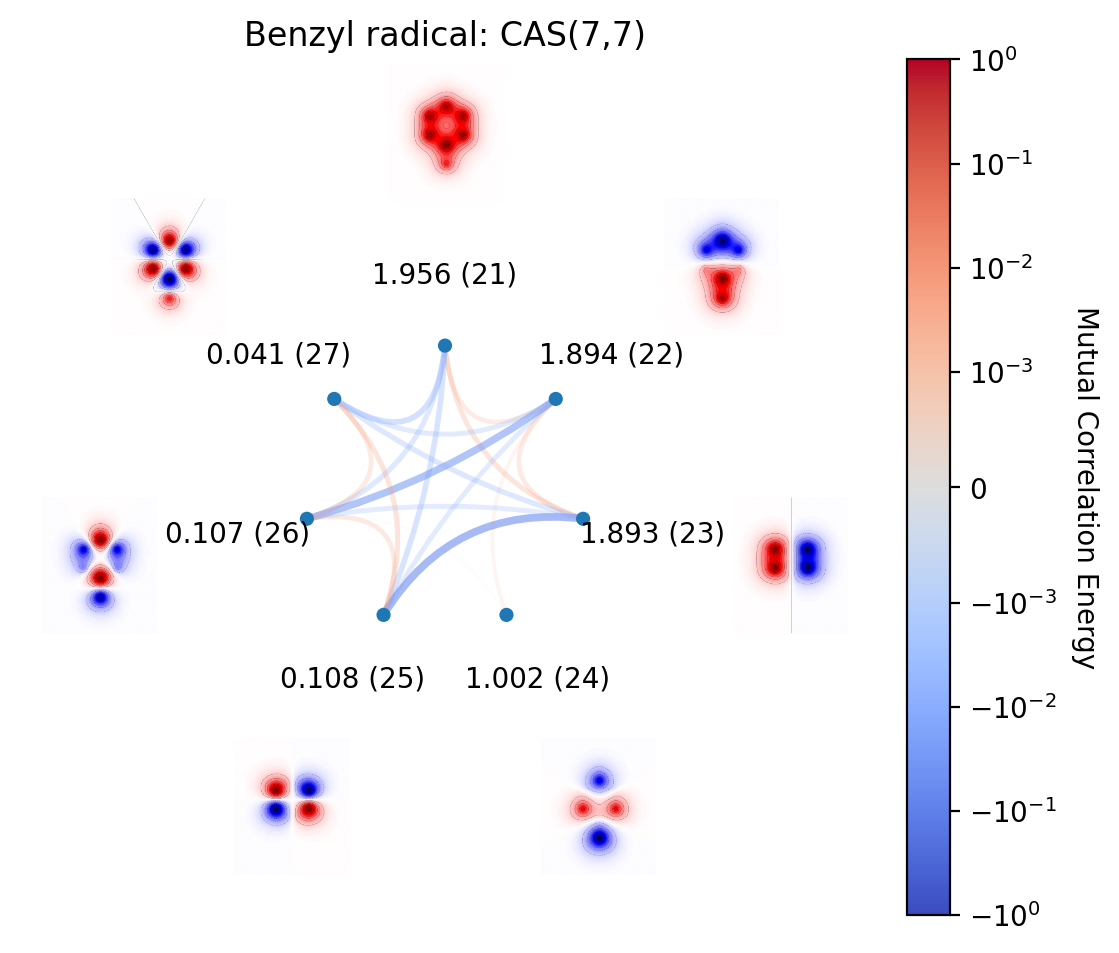

In [5]:
#benzyl radical
xyz="""
C 0.0000000 0.0000000 -0.9239991 
C -1.2194133 0.0000000 -0.1787713 
C -1.2130861 0.0000000 1.2077226 
C 0.0000000 0.0000000 1.9145870 
C 1.2130861 0.0000000 1.2077226 
C 1.2194133 0.0000000 -0.1787713 
H -2.1662300 0.0000000 -0.7227915 
H -2.1585579 0.0000000 1.7528538 
H 0.0000000 0.0000000 3.0050230 
H 2.1585579 0.0000000 1.7528538 
H 2.1662300 0.0000000 -0.7227915 
C 0.0000000 0.0000000 -2.3297274 
H -0.9331677 0.0000000 -2.8919553 
H 0.9331677 0.0000000 -2.8919553
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=0.5)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=2,ms=0.5))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )
mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Benzyl radical: CAS(7,7)",
                        occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   -1.74610524
   C   -2.30435717   0.00000000   -0.33782880
   C   -2.29240049   0.00000000   2.28226495
   C   0.00000000   0.00000000   3.61804507
   C   2.29240049   0.00000000   2.28226495
   C   2.30435717   0.00000000   -0.33782880
   H   -4.09358142   0.00000000   -1.36587798
   H   -4.07908326   0.00000000   3.31241362
   H   0.00000000   0.00000000   5.67867047
   H   4.07908326   0.00000000   3.31241362
   H   4.09358142   0.00000000   -1.36587798
   C   0.00000000   0.00000000   -8.18199898
   H   -1.76343138   0.00000000   -9.24445573
   H   1.76343138   0.00000000   -9.24445573
Parsed 14 atoms with basis set of 308 functions.
  Max eigenvalue: 7.915e+00
  Min eigenvalue: 4.864e-05
  Condition number: 1.627e+05
  Inverse condition number: 6.145e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 308
  Largest discarded ei

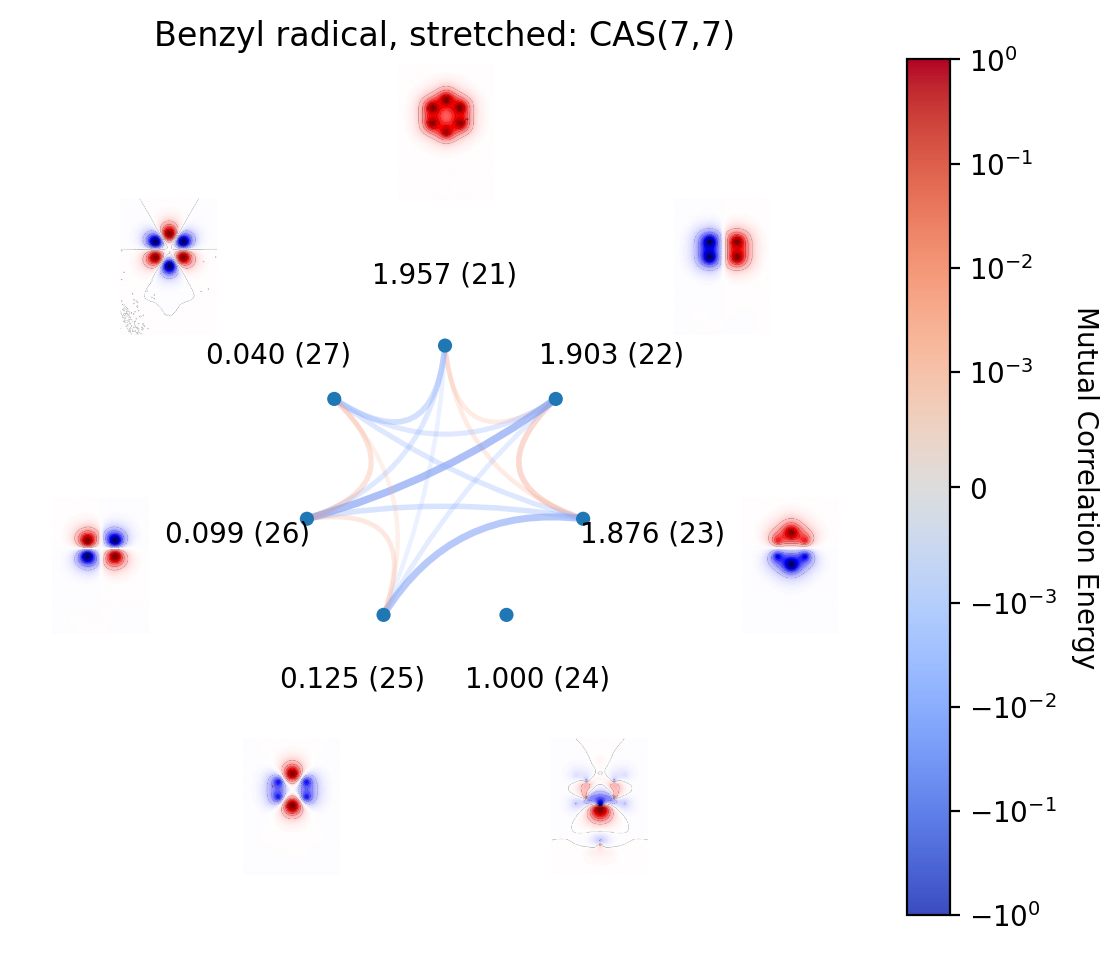

In [9]:
#benzyl radical w stretched bond
xyz="""
C 0.0000000 0.0000000 -0.9239991 
C -1.2194133 0.0000000 -0.1787713 
C -1.2130861 0.0000000 1.2077226 
C 0.0000000 0.0000000 1.9145870 
C 1.2130861 0.0000000 1.2077226 
C 1.2194133 0.0000000 -0.1787713 
H -2.1662300 0.0000000 -0.7227915 
H -2.1585579 0.0000000 1.7528538 
H 0.0000000 0.0000000 3.0050230 
H 2.1585579 0.0000000 1.7528538 
H 2.1662300 0.0000000 -0.7227915 
C 0.0000000 0.0000000 -4.3297274 
H -0.9331677 0.0000000 -4.8919553 
H 0.9331677 0.0000000 -4.8919553
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=0.5)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=2,ms=0.5))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )
mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Benzyl radical, stretched: CAS(7,7)",
                        occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   -1.78928661   0.00000000   -1.62750622
   C   -2.20560443   0.00000000   0.93494824
   C   0.00000000   0.00000000   2.41992243
   C   2.20560443   0.00000000   0.93494824
   C   1.78928661   0.00000000   -1.62750622
   C   0.00000000   0.00000000   -3.46812989


   H   -4.10446587   0.00000000   1.73494886
   H   0.00000000   0.00000000   4.48935867
   H   4.10446587   0.00000000   1.73494886
   H   0.00000000   0.00000000   -5.52593298
Parsed 10 atoms with basis set of 236 functions.
  Max eigenvalue: 8.024e+00
  Min eigenvalue: 6.965e-05
  Condition number: 1.152e+05
  Inverse condition number: 8.680e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 236
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.965e-05
Number of electrons: 40
Number of alpha electrons: 21
Number of beta electrons: 19
Ms: 1.0
Total charge: 0
Number of basis functions: 236
Number of orthogonalized basis functions: 236
Number of auxiliary basis functions: 522
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.44 GB (doubled due to storing B_nPm)
Number of system basis functions: 236
Number of auxiliary basis functions: 5

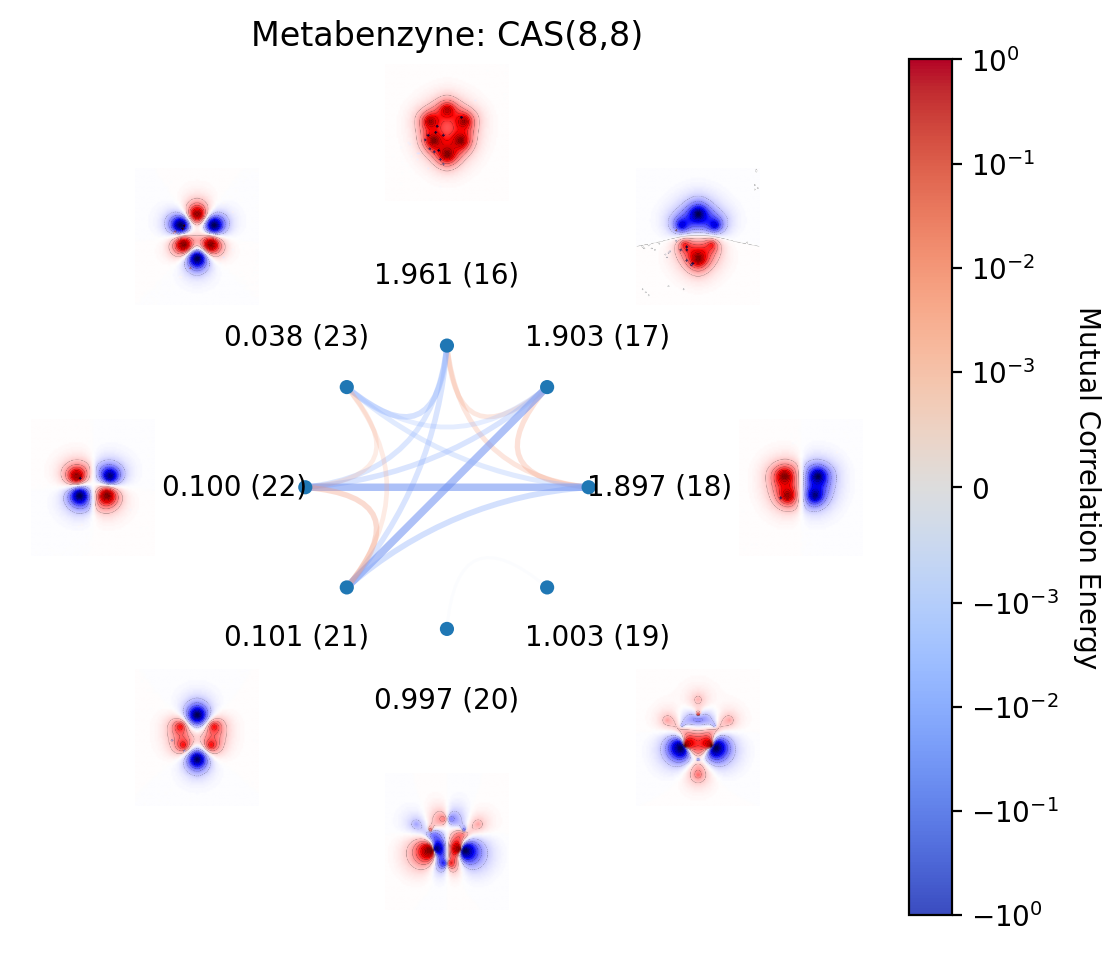

In [8]:
#metabenzyne
xyz="""
C -0.9468497 0.0000000 -0.8612392 
C -1.1671556 0.0000000 0.4947533 
C 0.0000000 0.0000000 1.2805678 
C 1.1671556 0.0000000 0.4947533 
C 0.9468497 0.0000000 -0.8612392 
C 0.0000000 0.0000000 -1.8352553 
H -2.1719898 0.0000000 0.9180954 
H 0.0000000 0.0000000 2.3756663 
H 2.1719898 0.0000000 0.9180954 
H 0.0000000 0.0000000 -2.9241978
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=3,ms=1.0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )
mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Metabenzyne: CAS(8,8)",
                        occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        )

### TM Hydrides

In [ ]:
xyz = """
Cu 0.000 0.000 0.000
H 0.000 1.463 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='total',
                   subspace=['Cu(3d)', 'Cu(4d)'],
                   num_active=10)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=1,ms=0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   CU   0.00000000   0.00000000   0.00000000
   H   0.00000000   2.76466932   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 4.664e+00
  Min eigenvalue: 6.738e-04
  Condition number: 6.922e+03
  Inverse condition number: 1.445e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.738e-04
Number of electrons: 30
Number of alpha electrons: 15
Number of beta electrons: 15
Ms: 0
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis funct

MCOptimizer(ci_solver=CISolver(states=State(multiplicity=1, ms=0, nel=30, system=System(atoms=[[29, array([0., 0., 0.])], [1, array([0.        , 2.76466932, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 82 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 282 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=15, nb=15, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=82, active_orbitals=[[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]], core_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=None, frozen_virtual_orbitals=None, die_if_not_converged=False, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e

In [ ]:
orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )
print(MCEmat)

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[ 0.          0.00281959  0.00277511  0.00277511  0.0038806  -0.00434005
  -0.00245925 -0.0137263  -0.0023497  -0.00245004]
 [ 0.00281959  0.          0.00277511  0.00277511  0.0038806  -0.00323525
  -0.02345324 -0.0024209  -0.0023497  -0.00245004]
 [ 0.00277511  0.00277511  0.          0.00367364  0.00297151 -0.00285245
  -0.00238232 -0.00389591 -0.00290711 -0.01419334]
 [ 0.00277511  0.00277511  0.00367364  0.          0.00297151 -0.00285245
  -0.00238232 -0.0023934  -0.02323606 -0.00296712]
 [ 0.0038806   0.0038806   0.00297151  0.00297151  0.         -0.01642002
  -0.00313372 -0.00306153 -0.0026034  -0.00470525]
 [-0.00434005 -0.00323525 -0.00285245 -0.00285245 -0.01642002  0.
   0.00256991  0.00256126  0.00201349  0.00211016]
 [-0.00245925 -0.02345324 -0.00238232 -0.00238232 -0.00313372  0.00256991
   0.          0.00184176  0.00179911  0.00189097]
 [-0.0137263  -0.0024209  -0.00389591 -0.0023934  -0.00306153  0.00256126
   0.00184176  0. 


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 54 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]



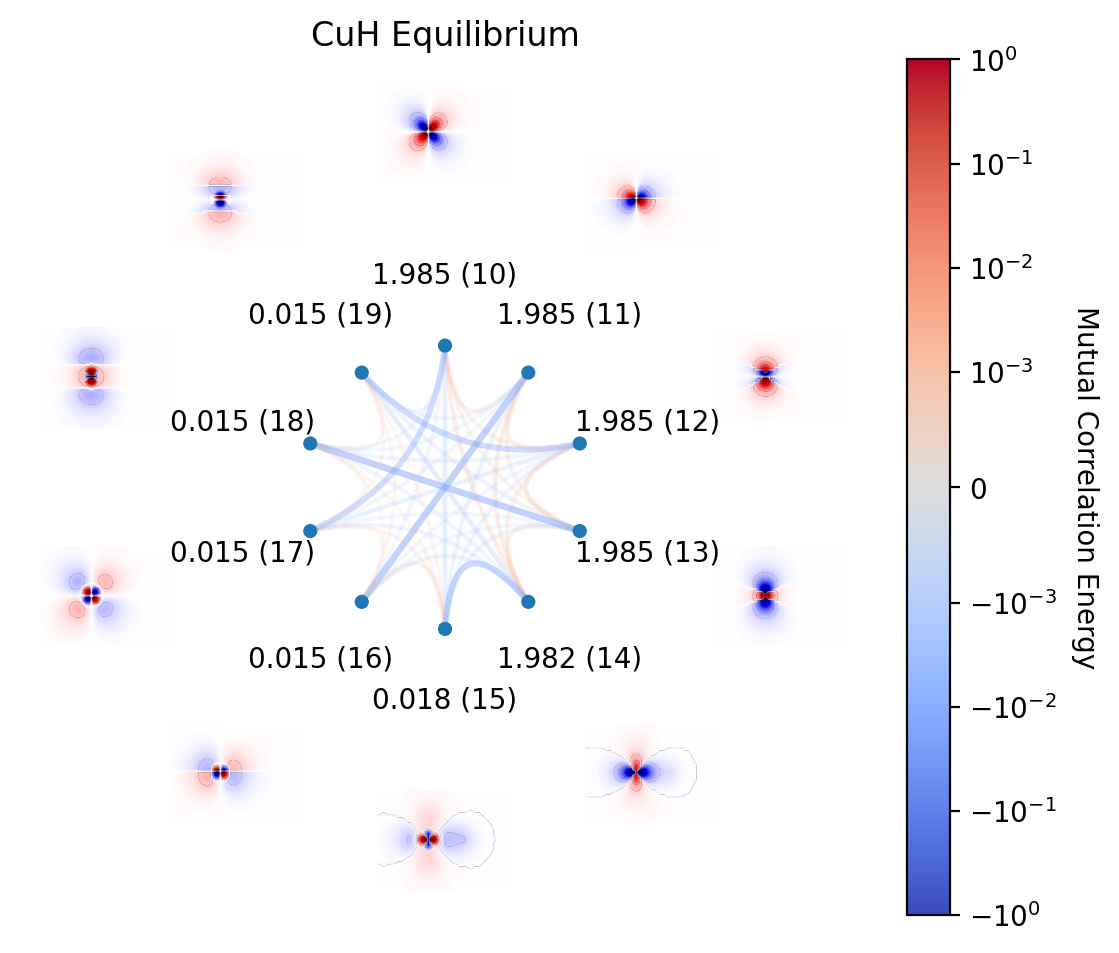

In [ ]:
mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="CuH Equilibrium",
                        occupation_numbers=ci.nat_occs
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   CU   0.00000000   0.00000000   0.00000000
   H   0.00000000   6.54412157   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 3.217e+00
  Min eigenvalue: 9.772e-04
  Condition number: 3.292e+03
  Inverse condition number: 3.037e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 9.772e-04
Number of electrons: 30
Number of alpha electrons: 15
Number of beta electrons: 15
Ms: 0
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis funct

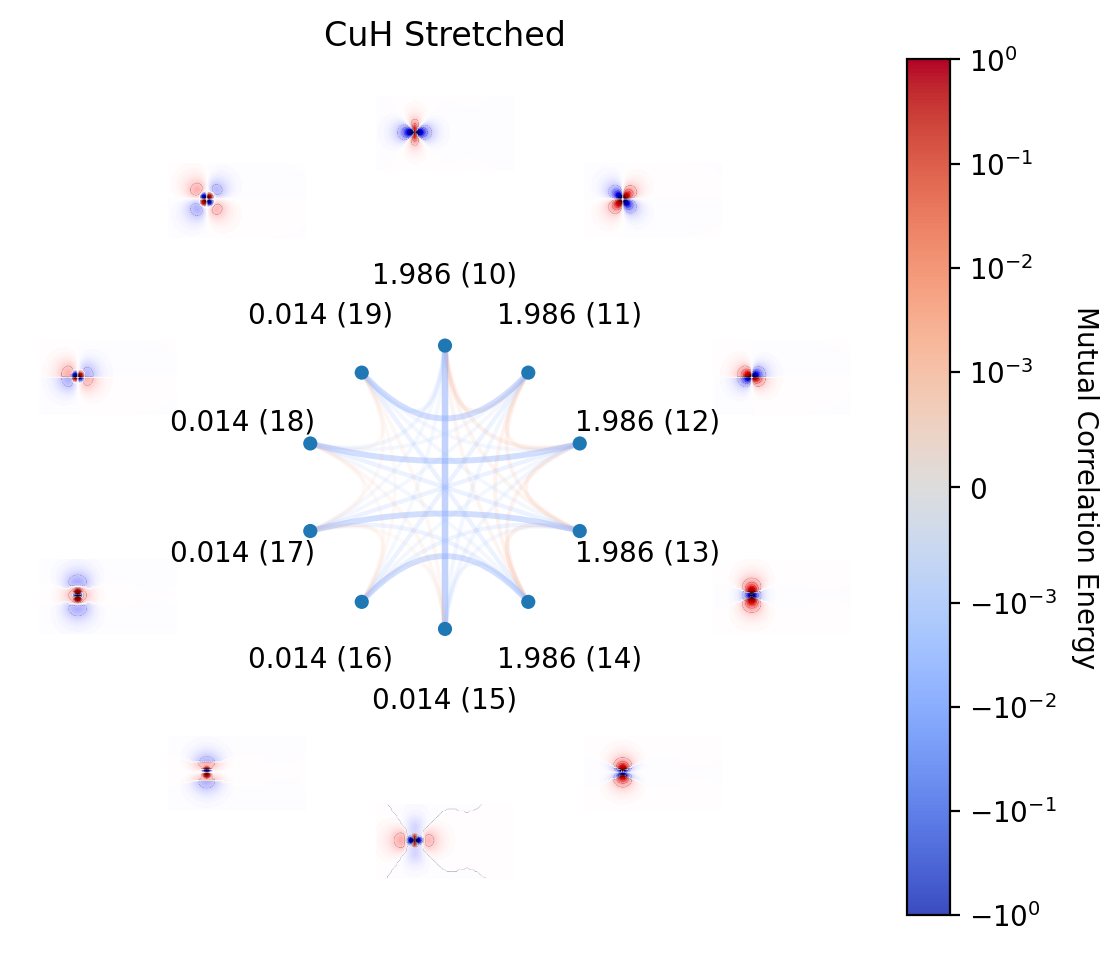

In [ ]:
xyz = """
Cu 0.000 0.000 0.000
H 0.000 3.463 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='total',
                   subspace=['Cu(3d)', 'Cu(4d)'],
                   num_active=10)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=1,ms=0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="CuH Stretched",
                        occupation_numbers=ci.nat_occs
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   NI   0.00000000   2.74766179   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 4.623e+00
  Min eigenvalue: 5.159e-04
  Condition number: 8.963e+03
  Inverse condition number: 1.116e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00


  Smallest kept eigenvalue: 5.159e-04
Number of electrons: 29
Number of alpha electrons: 15
Number of beta electrons: 14
Ms: 0.5
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis functions: 282
Iter               Energy           ΔE       ||ΔD||  ||AO grad||      <S^2>  DIIS
---------------------------------------------------------------------------------
   1   -1493.088171045619   1.4952e+00   8.5264e+00   5.6300e+00    0.75000     S
   2   -1503.126379803648  -1.0038e+01   7.4197e+00   9.5901e+00    0.75000   S/E
   3   -1506.614036672115  -3.4877e+00   1.7294e+00   4.6938e+00    0.75000   S/E
   4   -1507.239034489192  -6.2500e-01   1.1150e+00   

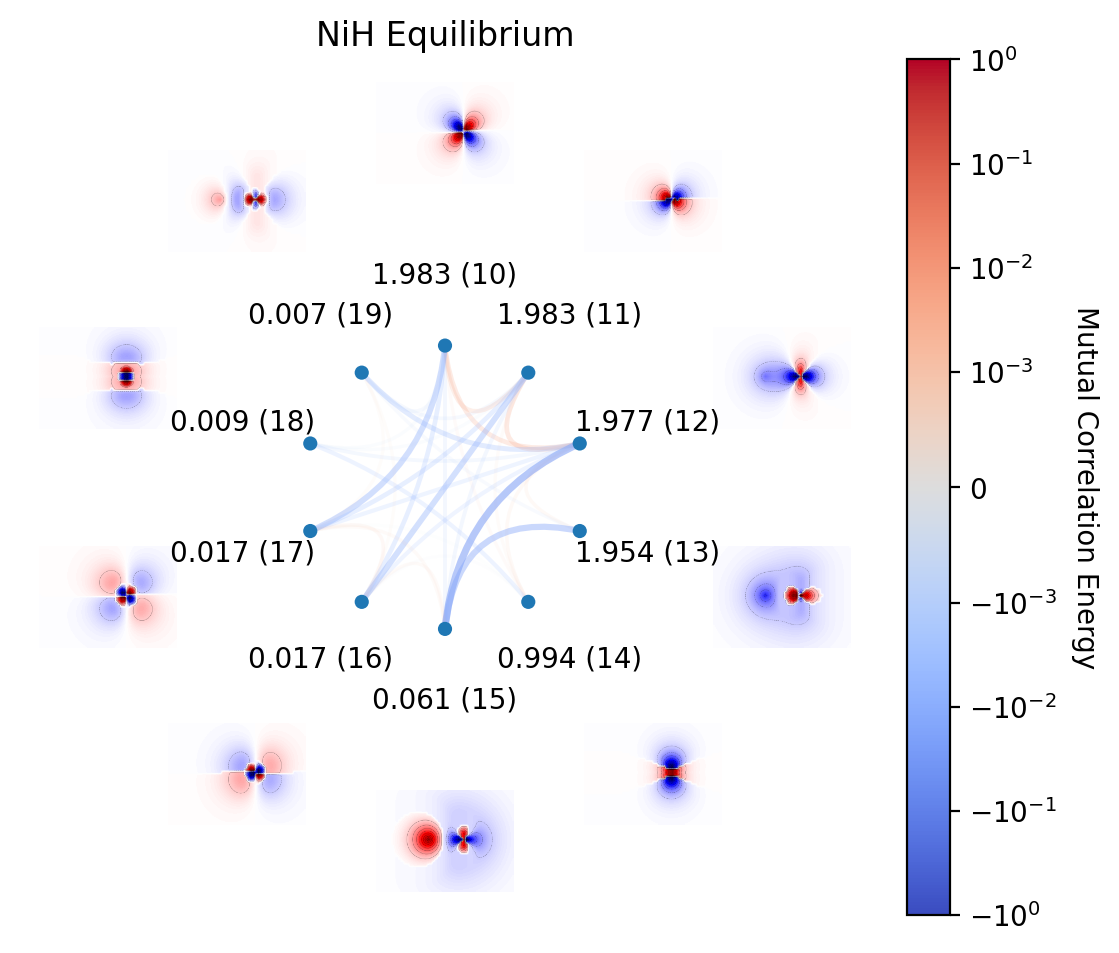

In [ ]:
xyz = """
H 0.000 0.000 0.000
Ni 0.000 1.454 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")
scf = forte2.ROHF(charge=0,ms=0.5)(system)
scf.run()

avas = forte2.AVAS(subspace=["Ni(3d)","Ni(4d)"],
                    selection_method="total",
                    num_active=10)(scf)
    
ci = forte2.CISolver(forte2.State(nel=29, multiplicity=2, ms=0.5),
    active_orbitals=10,
    core_orbitals=10,
    )
mc = forte2.MCOptimizer(ci,maxiter=100)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="NiH Equilibrium",
                        occupation_numbers=ci.nat_occs
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   NI   0.00000000   6.52711403   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 3.160e+00
  Min eigenvalue: 8.763e-04
  Condition number: 3.607e+03
  Inverse condition number: 2.773e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.763e-04
Number of electrons: 29
Number of alpha electrons: 15
Number of beta electrons: 14
Ms: 0.5
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis fu

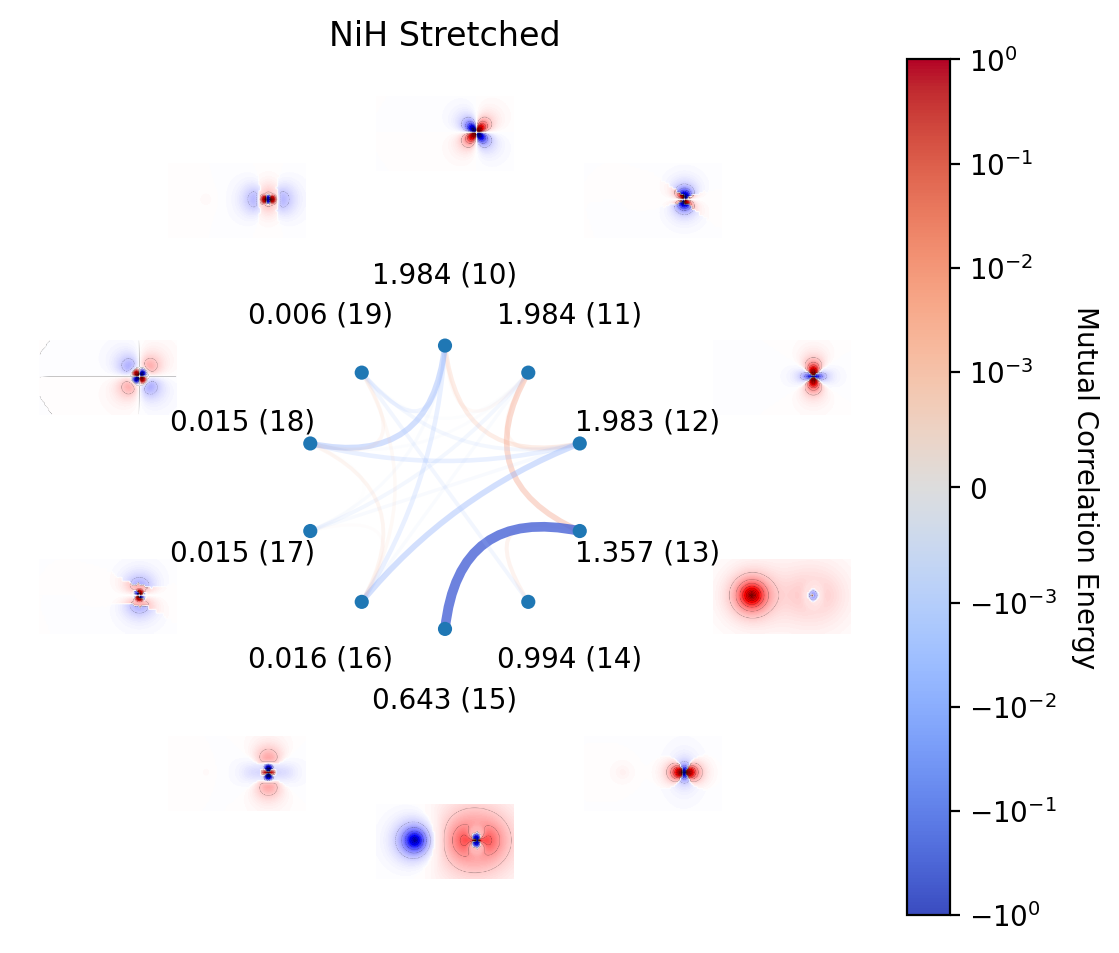

In [ ]:
xyz = """
H 0.000 0.000 0.000
Ni 0.000 3.454 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")
scf = forte2.ROHF(charge=0,ms=0.5)(system)
scf.run()

avas = forte2.AVAS(subspace=["Ni(3d)","Ni(4d)"],
                    selection_method="total",
                    num_active=10)(scf)
    
ci = forte2.CISolver(forte2.State(nel=29, multiplicity=2, ms=0.5),
    active_orbitals=10,
    core_orbitals=10,
    )
mc = forte2.MCOptimizer(ci,maxiter=100)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = np.zeros((len(orb_list),len(orb_list)))
for i in range(0,len(orb_list)):
    for j in range(0,len(orb_list)):
        if orb_list[i] != orb_list[j]: 
            MCEmat[i,j] = twofrag_correlation_energy_enumerated(ci=ci,
                                                                A_orbs=[orb_list[i]],
                                                                B_orbs=[orb_list[j]],
                                                                core_orbitals=ci.core_indices,
                                                                )

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="NiH Stretched",
                        occupation_numbers=ci.nat_occs
                        )